In [2]:
###########  Improved version of price vs area model  using simple linear regression

In [3]:
## import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import ( mean_absolute_error,mean_squared_error,r2_score)

In [5]:
### loading dataset

df=pd.read_csv('MagicBricks.csv')

In [6]:
df

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0
...,...,...,...,...,...,...,...,...,...,...,...
1254,4118.0,4,5.0,Unfurnished,Chittaranjan Park,3.0,55000000,Ready_to_move,New_Property,Builder_Floor,12916.0
1255,1050.0,3,2.0,Semi-Furnished,Chittaranjan Park,3.0,12500000,Ready_to_move,Resale,Builder_Floor,12916.0
1256,875.0,3,3.0,Semi-Furnished,Chittaranjan Park,3.0,17500000,Ready_to_move,New_Property,Builder_Floor,12916.0
1257,990.0,2,2.0,Unfurnished,Chittaranjan Park Block A,1.0,11500000,Ready_to_move,Resale,Builder_Floor,12916.0


In [7]:
### data cleaning

# Remove missing values
# Only important columns are checked


In [9]:
df=df.dropna(subset=['Area','Price'])

In [10]:
df

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0
...,...,...,...,...,...,...,...,...,...,...,...
1254,4118.0,4,5.0,Unfurnished,Chittaranjan Park,3.0,55000000,Ready_to_move,New_Property,Builder_Floor,12916.0
1255,1050.0,3,2.0,Semi-Furnished,Chittaranjan Park,3.0,12500000,Ready_to_move,Resale,Builder_Floor,12916.0
1256,875.0,3,3.0,Semi-Furnished,Chittaranjan Park,3.0,17500000,Ready_to_move,New_Property,Builder_Floor,12916.0
1257,990.0,2,2.0,Unfurnished,Chittaranjan Park Block A,1.0,11500000,Ready_to_move,Resale,Builder_Floor,12916.0


In [11]:
df.isnull().sum()

Area             0
BHK              0
Bathroom         2
Furnishing       5
Locality         0
Parking         33
Price            0
Status           0
Transaction      0
Type             5
Per_Sqft       241
dtype: int64

In [12]:
## remove duplicate rows

df=df.drop_duplicates()

In [13]:
df

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0
...,...,...,...,...,...,...,...,...,...,...,...
1254,4118.0,4,5.0,Unfurnished,Chittaranjan Park,3.0,55000000,Ready_to_move,New_Property,Builder_Floor,12916.0
1255,1050.0,3,2.0,Semi-Furnished,Chittaranjan Park,3.0,12500000,Ready_to_move,Resale,Builder_Floor,12916.0
1256,875.0,3,3.0,Semi-Furnished,Chittaranjan Park,3.0,17500000,Ready_to_move,New_Property,Builder_Floor,12916.0
1257,990.0,2,2.0,Unfurnished,Chittaranjan Park Block A,1.0,11500000,Ready_to_move,Resale,Builder_Floor,12916.0


In [14]:
df.head()

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0


In [15]:
df.info()

<class 'pandas.DataFrame'>
Index: 1176 entries, 0 to 1258
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Area         1176 non-null   float64
 1   BHK          1176 non-null   int64  
 2   Bathroom     1175 non-null   float64
 3   Furnishing   1171 non-null   str    
 4   Locality     1176 non-null   str    
 5   Parking      1145 non-null   float64
 6   Price        1176 non-null   int64  
 7   Status       1176 non-null   str    
 8   Transaction  1176 non-null   str    
 9   Type         1171 non-null   str    
 10  Per_Sqft     949 non-null    float64
dtypes: float64(4), int64(2), str(5)
memory usage: 110.2 KB


In [17]:
df.describe()

,Area,BHK,Bathroom,Parking,Price,Per_Sqft
count,1176.000000,1176.000000,1175.000000,1145.000000,1.176000e+03,949.000000
mean,1447.542711,2.789966,2.552340,1.979039,2.109173e+07,15817.306639
std,1487.658687,0.960993,1.053319,6.493508,2.523174e+07,21761.574205
min,28.000000,1.000000,1.000000,1.000000,1.000000e+06,1259.000000
25%,800.000000,2.000000,2.000000,1.000000,5.800000e+06,6471.000000
50%,1172.500000,3.000000,2.000000,1.000000,1.400000e+07,11111.000000
75%,1700.000000,3.000000,3.000000,2.000000,2.600000e+07,18000.000000
max,24300.000000,10.000000,7.000000,114.000000,2.400000e+08,183333.000000


In [20]:
## remove outliers using IQR

Q1=df[['Area','Price']].quantile(0.25)
Q3=df[['Area','Price']].quantile(0.75)
IQR=Q3-Q1

## keeping rows is normal range

df = df[
    ~((df[['Area','Price']]<(Q1-1.5*IQR))|
      (df[['Area','Price']]>(Q3+1.5*IQR))).any(axis=1)
]

In [21]:
df


,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0
...,...,...,...,...,...,...,...,...,...,...,...
1252,1800.0,3,3.0,Semi-Furnished,"Nehru Enclave, Kalkaji",1.0,26000000,Ready_to_move,Resale,Builder_Floor,12916.0
1253,1200.0,3,3.0,Semi-Furnished,Chittaranjan Park,1.0,16500000,Ready_to_move,Resale,Builder_Floor,12916.0
1255,1050.0,3,2.0,Semi-Furnished,Chittaranjan Park,3.0,12500000,Ready_to_move,Resale,Builder_Floor,12916.0
1256,875.0,3,3.0,Semi-Furnished,Chittaranjan Park,3.0,17500000,Ready_to_move,New_Property,Builder_Floor,12916.0


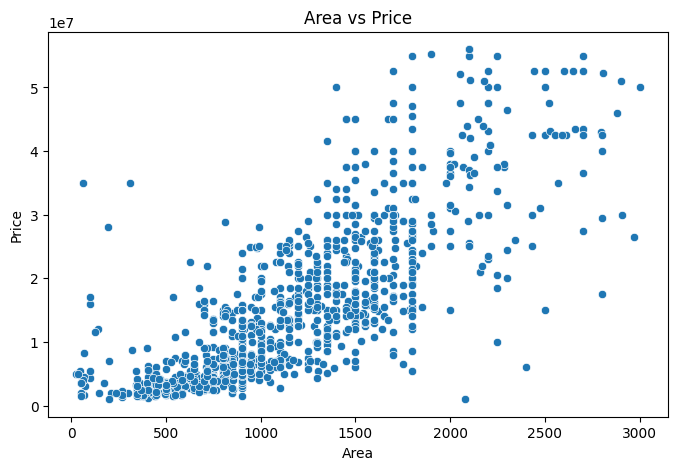

In [22]:
### EDA

plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Area',
    y='Price',
    data=df
)

plt.title('Area vs Price')
plt.show()



In [23]:
## correlation

correlation = df[['Area','Price']].corr()
print(correlation)

           Area     Price
Area   1.000000  0.786297
Price  0.786297  1.000000


In [24]:
## feature selection

x=df[['Area']]
y=df['Price']

In [25]:
### Train test split

X_train,X_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)


In [26]:
## model training

model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
## prediction

y_pred = model.predict(X_test)


In [28]:
y_pred

array([ 2971648.67848541, 10817733.53151457, 13084380.2668341 ,
       21715073.60516618, 15769484.86098186, 20407392.79632799,
       12561307.94329883, 17792031.1786516 , 20494571.5169172 ,
         565515.99022314,  7679299.59030291, 17094601.4139379 ,
       16048456.76686734, 13921295.98449055, 23894541.6198965 ,
        8202371.91383818, 10890398.73870009,  8150064.68148466,
        2099861.47259328,  7330584.70794605, 21279180.00222011,
       12561307.94329883, 16920243.97275947, 21279180.00222011,
        9074159.11973031, 15176669.56097521, 19535605.59043586,
       19535605.59043586,  1402431.70787958, 12212593.06094198,
       10817733.53151457, 22674039.53164752, 12561307.94329883,
       14304882.35508309, 20407392.79632799, 10817733.53151457,
        9074159.11973031, 23022754.41400437, 14304882.35508309,
       26509903.23757289, 10817733.53151457, 16048456.76686734,
        8202371.91383818, 18838175.82572215, 14304882.35508309,
       26509903.23757289, 42202072.94363

In [29]:
## custom prediction
sample_area = pd.DataFrame({'Area': [800]})
predicted_price = model.predict(sample_area)

print(f"Predicted Price for 800 sq.ft: {predicted_price[0]:.2f}")


Predicted Price for 800 sq.ft: 9074159.12


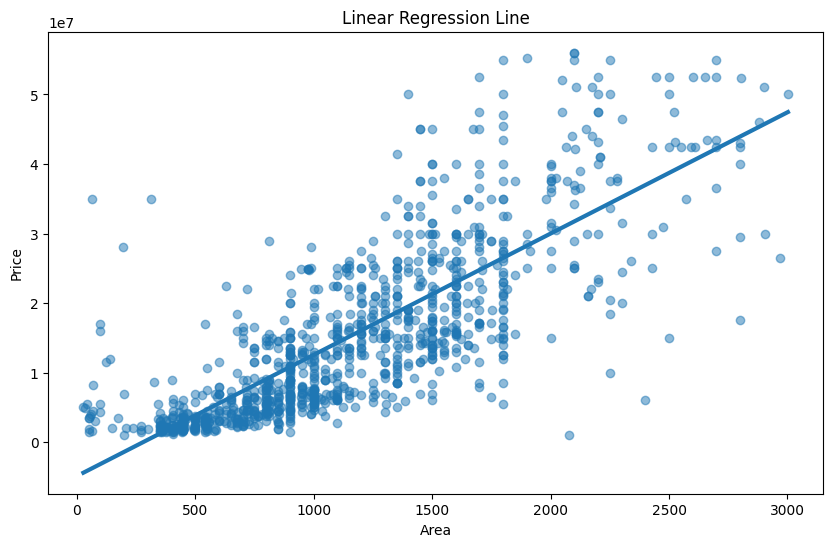

In [30]:
# REGRESSION LINE VISUALIZATION
# ===============================

sorted_df = df.sort_values(by='Area')

plt.figure(figsize=(10, 6))

plt.scatter(df['Area'], df['Price'], alpha=0.5)

plt.plot(
    sorted_df['Area'],
    model.predict(sorted_df[['Area']]),
    linewidth=3
)

plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Linear Regression Line')

plt.show()

In [31]:
# MODEL EVALUATION
# ===============================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")

MAE  : 5789679.79
MSE  : 65919672346145.12
RMSE : 8119093.07
R2   : 0.5433


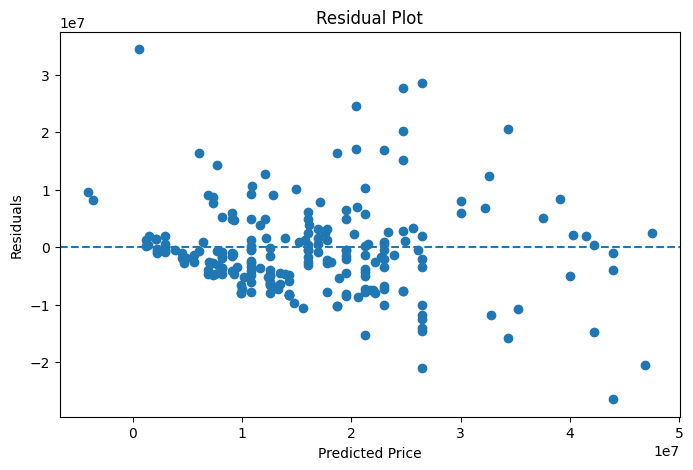

In [32]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle='--')

plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.show()